In [41]:
from __future__ import annotations
import sys; sys.path.insert(0, '..')

%load_ext autoreload
%autoreload 2


# python
import os
import ssl
import csv

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import session_info

from pathlib import Path
from inspect import cleandoc

# utils
from utils import Constants
from modules.preprocesing import preprocess
from modules import build_feature_pipeline

from wordcloud import WordCloud

# text
import re
import ast
import spacy
import unidecode
import pyLDAvis.gensim_models as gensimvis

# models
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    umap = None
    UMAP_AVAILABLE = False
    
from sklearn.decomposition import PCA
from sklearn.decomposition import LatentDirichletAllocation

# sklearn
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel, cosine_similarity, cosine_distances
from sklearn.cluster import KMeans, MiniBatchKMeans, AgglomerativeClustering, DBSCAN

# Metrics
from sklearn.metrics import silhouette_score

# stat
from scipy import stats

# statsmodels
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# typings
from pandas import DataFrame as PandasDF
from typing import List, Dict, Union

# setup
plt.style.use('seaborn-v0_8')
pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('max_colwidth', None)
# decimals
np.set_printoptions(precision=6)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [14]:
# cargar el dataset sklearn
if not os.environ.get('CI'):
    ssl._create_default_https_context =\
        ssl._create_unverified_context
          
# rutas absolutas
here: Path = Path.cwd().absolute().parent
data: Path = here / 'data'

poetry_fundation_cleaned: Path = data / 'CleanedPoetryFoundationData.csv'
cv_poetry: Path = data / 'vallejo_poems_en.csv'

# archivo cacheado con poemas ya preprocesados
poems_processed_cache: Path = data / 'poems_processed.csv'

In [15]:
setup_load:Dict = dict(
    sep=Constants.PIPE_STR,
    quotechar=Constants.QUOTECHAR_STR,
    quoting=csv.QUOTE_NONNUMERIC,
    encoding=Constants.ENCODING
)

setup_save: Dict = dict(
    sep=Constants.PIPE_STR,
    quotechar=Constants.QUOTECHAR_STR,
    quoting=csv.QUOTE_NONNUMERIC,
    encoding=Constants.ENCODING,
    index=False
)

if not poetry_fundation_cleaned.is_file() or not cv_poetry.is_file():
    raise FileNotFoundError(
        cleandoc(f'''
        El archivo {poetry_fundation_cleaned} no existe.
        Por favor, descargue el archivo desde:
        https://www.kaggle.com/datasets/abhinavwalia95/poetryfoundationorg
        y coloquelo en la carpeta data.
        ''')
    )


def parse_tags(value):
    """
    Convierte tags a lista.
    Soporta listas reales, strings tipo "['Love', 'Nature']" o strings separados por coma.
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        parsed = ast.literal_eval(str(value))
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except (ValueError, SyntaxError):
        return [
            tag.strip()
            for tag in str(value).split(Constants.COMMA_STR)
            if tag.strip()
        ]


if poems_processed_cache.is_file():
    print(f"Cargando poemas preprocesados desde: {poems_processed_cache}")

    new_poems_df: PandasDF = pd.read_csv(
        str(poems_processed_cache),
        **setup_load
    )
    
    # Al leer desde CSV, tags vuelve como string; se normaliza a lista.
    if "tags" in new_poems_df.columns:
        new_poems_df["tags"] = new_poems_df["tags"].apply(parse_tags)

else:
    print("No existe cache preprocesado. Se procesarán los poemas con spaCy...")

    poetry_df: PandasDF = (
        pd.read_csv(
            str(poetry_fundation_cleaned), 
            **setup_load
        )
        .dropna(subset=['title', 'poem'])
        .reset_index(drop=True)
    )

    cv_df: PandasDF = (
            pd.read_csv(
            str(cv_poetry), 
            **setup_load
        )
        .dropna(subset=['title', 'poem'])
        .reset_index(drop=True)
    )
    
    # Mantener fuente para trazabilidad
    # Metadata Poetry Foundation
    poetry_df["source"] = "poetry_foundation"
    
    if "poet" not in poetry_df.columns:
        poetry_df["poet"] = "unknown"

    if "tags" not in poetry_df.columns:
        poetry_df["tags"] = [[] for _ in range(len(poetry_df))]
    else:
        poetry_df["tags"] = poetry_df["tags"].apply(parse_tags)
    
    # Metadata César Vallejo
    cv_df["source"] = "cesar_vallejo"
    cv_df["poet"] = "César Vallejo"
    cv_df["tags"] = [[] for _ in range(len(cv_df))]
    
    # Unificar corpus
    new_poems_df: PandasDF = (
        pd.concat(
            [
                poetry_df[["title", "poet", "poem", "tags", "source"]],
                cv_df[["title", "poet", "poem", "tags", "source"]]
            ],
            ignore_index=True
        )
        .dropna(subset=["title", "poem"])
        .reset_index(drop=True)
    )
    
    # Guardar texto original y texto procesado por separado
    new_poems_df["poem_raw"] = new_poems_df["poem"].astype(str)
    
    # Esta es la parte lenta: spaCy + limpieza + stopwords + stemming/lemma
    new_poems_df["poem_processed"] = (
        new_poems_df["poem_raw"]
        .astype(str)
        .apply(preprocess)
    )

    # Guardar cache para no repetir preprocess() en cada corrida
    new_poems_df.to_csv(
        poems_processed_cache,
        **setup_save
    )

    print(f"Cache generado en: {poems_processed_cache}")


No existe cache preprocesado. Se procesarán los poemas con spaCy...
Cache generado en: /Users/ronaldmendoza/Documents/Documents/Repos/GitHub/projects/_hubertronald/VersoVector/data/poems_processed.csv


In [18]:
display(new_poems_df.loc[new_poems_df.source == "poetry_foundation", :].head(3))

,title,poet,poem,tags,source,poem_raw,poem_processed
0,invis fish,joy harjo,invis fish swim ghost ocean describ wave sand waterworn rock soon fish learn walk human come ashor paint dream die stone later later ocean floor punctuat chevi truck carri dreamer decend go store,"[living, time brevity, relationships, family ancestors, nature, landscapes pastorals, seas, rivers, streams, social commentaries, history politics]",poetry_foundation,invis fish swim ghost ocean describ wave sand waterworn rock soon fish learn walk human come ashor paint dream die stone later later ocean floor punctuat chevi truck carri dreamer decend go store,invi fish swim ghost ocean describ wave sand waterworn rock soon fish learn walk human come ashor paint dream die stone later later ocean floor punctuat chevi truck carri dreamer decend store
1,not bother earth spirit,joy harjo,not bother earth spirit live work stori oldest stori world delic chang see watch invit coffe warm bread oblig stay listen ordinari stori endur earthquak lightn death love blind beauti stori compel want leav trap stone finger escap,"[religion, the spiritual, mythology folklore, fairytales legends]",poetry_foundation,not bother earth spirit live work stori oldest stori world delic chang see watch invit coffe warm bread oblig stay listen ordinari stori endur earthquak lightn death love blind beauti stori compel want leav trap stone finger escap,bother earth spirit live work stori old stori world delic chang watch invit coff warm bread oblig stay listen ordinari stori endur earthquak lightn death love blind beauti stori compel want leav trap stone finger escap
2,hour consid hydrangea,simon white,hour consid hydrangea salt sand plant variet question variet diet mother know pound feel like lose lose ye sens possibl beauti grow extern extern beauti beauti occur surfac plant sun darken skin child small beauti obviou beauti hand swell bite spread insect venom small appear feel smash skull floor scream hold lap kitchen floor open freezer press pack frozen clay forehead like cold obviou hydrangea walk push child stroller walk push haul lift have bodi adjunct bodi compos errand weight tender small power imagin feel small weight pound like interf twitch muscl bodi object mother confus middleag mother littl spare flesh feel inch major muscl pull graviti weight child sleep hour think hydrangea let man look stop brush drowsi child littl eye face bare consid mother consid miss subtl power differenti time mass apprehen,"[living, parenthood, the body, the mind, nature, trees flowers]",poetry_foundation,hour consid hydrangea salt sand plant variet question variet diet mother know pound feel like lose lose ye sens possibl beauti grow extern extern beauti beauti occur surfac plant sun darken skin child small beauti obviou beauti hand swell bite spread insect venom small appear feel smash skull floor scream hold lap kitchen floor open freezer press pack frozen clay forehead like cold obviou hydrangea walk push child stroller walk push haul lift have bodi adjunct bodi compos errand weight tender small power imagin feel small weight pound like interf twitch muscl bodi object mother confus middleag mother littl spare flesh feel inch major muscl pull graviti weight child sleep hour think hydrangea let man look stop brush drowsi child littl eye face bare consid mother consid miss subtl power differenti time mass apprehen,hour consid hydrangea salt sand plant variet question variet diet mother know pound feel like lose lose ye sen possibl beauti grow extern extern beauti beauti occur surfac plant sun darken skin child small beauti obviou beauti hand swell bite spread insect venom small appear feel smash skull floor scream hold lap kitchen floor open freezer press pack frozen clay forehead like cold obviou hydrangea walk push child stroller walk push haul lift bodi adjunct bodi compo errand weight tender small power imagin feel small weight pound like interf twitch muscl bodi object mother confu middleag moth

In [19]:
display(new_poems_df.loc[new_poems_df.source == "cesar_vallejo", :].head(3))

,title,poet,poem,tags,source,poem_raw,poem_processed
12641,The Black Heralds,César Vallejo,"There are blows in life, so powerful... I don't know!\nBlows as from God's hatred; as if before them,\nthe backlash of everything suffered\nwere to dam up in the soul... I don't know!\n\nThey are few; but they are . . . They open dark furrows\nin the fiercest face and in the strongest side.\nMaybe they could be the horses of barbarous Attilas;\nor the black heralds Death sends us.\n\nThey are the deep abysses of the soul's Christs,\nof some revered faith Destiny blasphemes.\nThose gory blows are the cracklings of a bread\nthat burns-up on us at the oven's door.\n\nAnd man . . . Poor . . . poor! He turns his eyes,\nas when a slap on the shoulder calls us;\nhe turns his crazed eyes, and everything lived\nis dammed up, like a pond of guilt, in his gaze.\nThere are blows in life, so powerful . . . I don't know!",[],cesar_vallejo,"There are blows in life, so powerful... I don't know!\nBlows as from God's hatred; as if before them,\nthe backlash of everything suffered\nwere to dam up in the soul... I don't know!\n\nThey are few; but they are . . . They open dark furrows\nin the fiercest face and in the strongest side.\nMaybe they could be the horses of barbarous Attilas;\nor the black heralds Death sends us.\n\nThey are the deep abysses of the soul's Christs,\nof some revered faith Destiny blasphemes.\nThose gory blows are the cracklings of a bread\nthat burns-up on us at the oven's door.\n\nAnd man . . . Poor . . . poor! He turns his eyes,\nas when a slap on the shoulder calls us;\nhe turns his crazed eyes, and everything lived\nis dammed up, like a pond of guilt, in his gaze.\nThere are blows in life, so powerful . . . I don't know!",blow life power not know blow god hatr backlash suffer dam soul not know open dark furrow fierce face strong mayb hors barbar attila black herald death send deep abyss soul christ rever faith destini blasphem gori blow crackl bread burnsup oven door man poor poor turn eye slap shoulder call turn craze eye live dam like pond guilt gaze blow life power not know
12642,Black Stone On Top Of A White Stone,César Vallejo,"I shall die in Paris, in a rainstorm,\nOn a day I already remember.\nI shall die in Paris- it does not bother me-\nDoubtless on a Thursday, like today, in autumn.\n\nIt shall be a Thursday, because today, Thursday\nAs I put down these lines, I have set my shoulders\nTo the evil. Never like today have I turned,\nAnd headed my whole journey to the ways where I am alone.\n\nCésar Vallejo is dead. They struck him,\nAll of them, though he did nothing to them,\nThey hit him hard with a stick and hard also\nWith the end of a rope. Witnesses are: the Thursdays,\nThe shoulder bones, the loneliness, the rain, and the roads...",[],cesar_vallejo,"I shall die in Paris, in a rainstorm,\nOn a day I already remember.\nI shall die in Paris- it does not bother me-\nDoubtless on a Thursday, like today, in autumn.\n\nIt shall be a Thursday, because today, Thursday\nAs I put down these lines, I have set my shoulders\nTo the evil. Never like today have I turned,\nAnd headed my whole journey to the ways where I am alone.\n\nCésar Vallejo is dead. They struck him,\nAll of them, though he did nothing to them,\nThey hit him hard with a stick and hard also\nWith the end of a rope. Witnesses are: the Thursdays,\nThe shoulder bones, the loneliness, the rain, and the roads...",shall die pari rainstorm day rememb shall die pari bother doubtless thursday like today autumn shall thursday today thursday line set shoulder evil like today turn head journey way cesar vallejo dead strike hit hard stick hard end rope wit thursday shoulder bone loneli rain road
12643,"Paris, October 1936 Poem",César Vallejo,"From all of this I am the only one who leaves.\nFrom this bench I go away, from my pants,\nfrom my great situation, from my actions,\nfrom my number split side to side,\nfrom all of this I am the only one who leaves.\n\nFrom the Champs

In [20]:
INPUT_IS_PROCESSED: bool = True

feature_pipeline = build_feature_pipeline(
    input_is_processed=INPUT_IS_PROCESSED
)
feature_pipeline

Pipeline(steps=[('Features',
                 FeatureUnion(transformer_list=[('CountVect',
                                                 CountVectorizer(stop_words='english')),
                                                ('Tfid',
                                                 TfidfVectorizer(max_features=5000,
                                                                 norm=None,
                                                                 smooth_idf=False,
                                                                 stop_words='english')),
                                                ('DictVect',
                                                 Pipeline(steps=[('TextToDictTransformer',
                                                                  TextToDictTransformer()),
                                                                 ('DictVectorizer',
                                                                  DictVectorizer())]))])),
                ('ToDense', ToDense()), ('Norm', Normalize())])

In [21]:
X_features = feature_pipeline.fit_transform(
    new_poems_df["poem_processed"].tolist()
)

X = X_features

# X representacion oficial no supervisada.
print("X_features shape:", X_features.shape)

X_features shape: (12645, 209130)


In [22]:
# 2. Vectorizar el texto
tfidf = TfidfVectorizer(max_features=5000) # Limitar a 5000 palabras más importantes
tfidf_matrix  = tfidf.fit_transform(new_poems_df.poem)

In [23]:
df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(), 
    index=new_poems_df.title, 
    columns=tfidf.get_feature_names_out()
)
display(df_tfidf)

abandon  abid  abil  abl  abraham  \
title                                                                    
invis fish                               0.0   0.0   0.0  0.0      0.0   
not bother earth spirit                  0.0   0.0   0.0  0.0      0.0   
hour consid hydrangea                    0.0   0.0   0.0  0.0      0.0   
scar                                     0.0   0.0   0.0  0.0      0.0   
remain                                   0.0   0.0   0.0  0.0      0.0   
...                                      ...   ...   ...  ...      ...   
fear                                     0.0   0.0   0.0  0.0      0.0   
The Black Heralds                        0.0   0.0   0.0  0.0      0.0   
Black Stone On Top Of A White Stone      0.0   0.0   0.0  0.0      0.0   
Paris, October 1936 Poem                 0.0   0.0   0.0  0.0      0.0   
XIII                                     0.0   0.0   0.0  0.0      0.0   

                                     abroad  absenc  absent  absolut  absorb  \
title                                                                          
invis fish                              0.0     0.0     0.0      0.0     0.0   
not bother earth spirit                 0.0     0.0     0.0      0.0     0.0   
hour consid hydrangea                   0.0     0.0     0.0      0.0     0.0   
scar                                    0.0     0.0     0.0      0.0     0.0   
remain                                  0.0     0.0     0.0      0.0     0.0   
...                                     ...     ...     ...      ...     ...   
fear                                    0.0     0.0     0.0      0.0     0.0   
The Black Heralds                       0.0     0.0     0.0      0.0     0.0   
Black Stone On Top Of A White Stone     0.0     0.0     0.0      0.0     0.0   
Paris, October 1936 Poem                0.0     0.0     0.0      0.0     0.0   
XIII                                    0.0     0.0     0.0      0.0     0.0   

                                     abstract  absurd  abund  abus  abyss  \
title                                                                       
invis fish                                0.0     0.0    0.0   0.0    0.0   
not bother earth spirit                   0.0     0.0    0.0   0.0    0.0   
hour consid hydrangea                     0.0     0.0    0.0   0.0    0.0   
scar                                      0.0     0.0    0.0   0.0    0.0   
remain                                    0.0     0.0    0.0   0.0    0.0   
...                                       ...     ...    ...   ...    ...   
fear                                      0.0     0.0    0.0   0.0    0.0   
The Black Heralds                         0.0     0.0    0.0   0.0    0.0   
Black Stone On Top Of A White Stone       0.0     0.0    0.0   0.0    0.0   
Paris, October 1936 Poem                  0.0     0.0    0.0   0.0    0.0   
XIII                                      0.0     0.0    0.0   0.0    0.0   

                                     accent  accept  access  accid  accident  \
title                                                                          
invis fish                              0.0     0.0     0.0    0.0       0.0   
not bother earth spirit                 0.0     0.0     0.0    0.0       0.0   
hour consid hydrangea                   0.0     0.0     0.0    0.0       0.0   
scar                                    0.0     0.0     0.0    0.0       0.0   
remain                                  0.0     0.0     0.0    0.0       0.0   
...                                     ...     ...     ...    ...       ...   
fear                                    0.0     0.0     0.0    0.0       0.0   
The Black Heralds                       0.0     0.0     0.0    0.0       0.0   
Black Stone On Top Of A White Stone     0.0     0.0     0.0    0.0       0.0   
Paris, October 1936 Poem                0.0     0.0     0.0    0.0       0.0   
XIII                                    0.0     0.0     0.0    0.0     

In [24]:
cosine_sim = cosine_similarity(X_features)
cosine_sim

array([[1.      , 0.017935, 0.04624 , ..., 0.019354, 0.021231, 0.011638],
       [0.017935, 1.      , 0.032634, ..., 0.030566, 0.038729, 0.020407],
       [0.04624 , 0.032634, 1.      , ..., 0.011356, 0.      , 0.021043],
       ...,
       [0.019354, 0.030566, 0.011356, ..., 1.      , 0.015232, 0.019481],
       [0.021231, 0.038729, 0.      , ..., 0.015232, 1.      , 0.025334],
       [0.011638, 0.020407, 0.021043, ..., 0.019481, 0.025334, 1.      ]])

In [25]:
def recomendador(title, cosine_sim=cosine_sim, df=new_poems_df):
    
    #Paso 2
    df = df.reset_index(drop=True)
    indices = pd.Series(df.index, index=df.title).drop_duplicates()
    #Paso 3
    idx = indices[title]

    #Paso 4
    sim_scores = list(enumerate(cosine_sim[idx]))

    #Paso 5
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    #Paso 6
    sim_scores = sim_scores[1:11]

    _indices = [i[0] for i in sim_scores]

    #Paso 7
    return pd.DataFrame(df.title.iloc[_indices])

In [29]:
display(recomendador('The Black Heralds'))

,title
623,aim song
9313,ballad salvat armi
1822,keumganggul diamond cave
6145,fortuna
3259,way wind blow
11911,princess splendour fall castl wall
1463,man short life foolish ambit
11882,memoriam h h obiit mdcccxxxiii
1644,curs name
8255,silent hous


In [30]:
def recommendation_corr(
    query_title: str,
    corr_matrix: pd.DataFrame,
    top_n: int = 5
) -> pd.DataFrame:
    """
    Genera recomendaciones basadas en correlación de Pearson entre documentos.

    Args:
        query_title (str): Documento de referencia.
        corr_matrix (pd.DataFrame): Matriz de correlaciones.
        top_n (int): Número de recomendaciones a devolver.

    Returns:
        pd.DataFrame: Recomendaciones con puesto, título y similitud.
        
    Nota:   La correlación de Pearson se mantiene como comparación exploratoria offline.
            Para recomendaciones en línea se usa similitud coseno por eficiencia y
            estabilidad en espacios vectoriales de texto.
            
            O(n_poemas² × n_features)
    """
    if query_title not in corr_matrix.columns:
        raise ValueError(f"El título '{query_title}' no está en la matriz de correlación.")

    # Extraer correlaciones con el documento de referencia
    sim_scores = corr_matrix[query_title].drop(query_title)

    # Ordenar de mayor a menor correlación
    sim_scores = sim_scores.sort_values(ascending=False).head(top_n)

    return pd.DataFrame({
        "Puesto": range(Constants.ONE, len(sim_scores) + Constants.ONE),
        "Recomendación": sim_scores.index,
        "Similitud": sim_scores.values
    })

In [31]:
# proceso lento porque calcula la matriz de correlación completa, 
# pero es para mostrar la diferencia entre métodos.
RUN_PEARSON_ANALYSIS = False

if RUN_PEARSON_ANALYSIS:
    df_features = pd.DataFrame(
        X_features,
        index=new_poems_df["title"]
    )

    corr_matrix = df_features.T.corr(method="pearson")

    recom_features_corr = recommendation_corr(
        query_title="black herald",
        corr_matrix=corr_matrix,
        top_n=5
    )

    display(recom_features_corr)
else:
    print("Pearson correlation analysis skipped. Use cosine similarity for online recommendations.")

Pearson correlation analysis skipped. Use cosine similarity for online recommendations.


In [32]:
def recommendation_pearson_fast(
    query_title: str,
    X: np.ndarray,
    df: pd.DataFrame,
    top_n: int = 5
) -> pd.DataFrame:
    """
    Recomendación (función vectorizada) por correlación de Pearson contra un solo poema,
    sin construir la matriz completa documento-documento.
    """

    df = df.reset_index(drop=True)
    indices = pd.Series(df.index, index=df.title).drop_duplicates()

    if query_title not in indices:
        raise ValueError(f"El título '{query_title}' no existe en el corpus.")

    idx = indices[query_title]

    X = np.asarray(X, dtype=np.float32)
    q = X[idx]

    n_features = X.shape[1]

    row_means = X.mean(axis=1)
    row_sumsq = np.square(X).sum(axis=1)

    q_mean = q.mean()
    q_sumsq = np.square(q).sum()

    numerator = X @ q - n_features * row_means * q_mean

    denominator = np.sqrt(
        row_sumsq - n_features * np.square(row_means)
    ) * np.sqrt(
        q_sumsq - n_features * q_mean**2
    )

    pearson_scores = np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=np.float32),
        where=denominator != 0
    )

    pearson_scores[idx] = -np.inf

    top_idx = np.argpartition(pearson_scores, -top_n)[-top_n:]
    top_idx = top_idx[np.argsort(pearson_scores[top_idx])[::-1]]

    return pd.DataFrame({
        "Puesto": range(1, len(top_idx) + 1),
        "Recomendación": df.title.iloc[top_idx].values,
        "Similitud Pearson": pearson_scores[top_idx]
    })

In [34]:
recom_pearson_fast = recommendation_pearson_fast(
    query_title="The Black Heralds",
    X=X_features,
    df=new_poems_df,
    top_n=5
)

display(recom_pearson_fast)

,Puesto,Recomendación,Similitud Pearson
0,1,aim song,0.223925
1,2,ballad salvat armi,0.208593
2,3,keumganggul diamond cave,0.206371
3,4,fortuna,0.203699
4,5,way wind blow,0.200024


In [36]:
topic_vectorizer = CountVectorizer(
    stop_words="english",
    max_features=5000
)

X_topics = topic_vectorizer.fit_transform(
    new_poems_df["poem_processed"].tolist()
)

# Modelo LDA con sklearn
lda_model = LatentDirichletAllocation(
    n_components=7,
    random_state=0
)

lda_topics = lda_model.fit_transform(X_topics)

# Identificar tema principal del poema 'black herald'
idx_cuento = new_poems_df[new_poems_df.title == 'The Black Heralds'].index[0]
tema_principal = lda_topics[idx_cuento].argmax()

# Probabilidades de pertenecer al tema principal
prob_tema_principal = lda_topics[:, tema_principal]

# Construir ranking de recomendaciones
df_recom = new_poems_df[["title"]].copy()
df_recom["prob_tema"] = prob_tema_principal

# eliminar el mismo poema 'black herald'
df_recom = df_recom[df_recom["title"] != 'The Black Heralds']

# ordenar por mayor probabilidad
df_recom = df_recom.sort_values("prob_tema", ascending=False)

# top N recomendaciones
top_recom = df_recom.head(5).reset_index(drop=True)
top_recom.insert(0, "Puesto", range(1, len(top_recom) + 1))

display(top_recom)

,Puesto,title,prob_tema
0,1,en la call san sebastian,0.994072
1,2,littl kitten lose mitten,0.987160
2,3,birth john henri,0.987154
3,4,malcolm x,0.985653
4,5,sleeper,0.985398


In [37]:
# LDA  “top palabras por tópico”
feature_names = topic_vectorizer.get_feature_names_out()

n_top = 10
top_words = []

for t, topic in enumerate(lda_model.components_):
    top_idx = topic.argsort()[::-1][:n_top]
    words = [feature_names[i] for i in top_idx]
    top_words.append((t, words))

display(
    pd.DataFrame({
        f"topic_{t}": words for t, words in top_words
    })
)

,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6
0,like,like,man,like,thi,like,man
1,know,light,come,know,love,let,like
2,think,tree,like,think,thou,bodi,know
3,world,water,hand,come,shall,sea,woman
4,word,white,blood,want,thee,time,good
5,time,leav,hear,time,man,sing,look
6,write,eye,dead,love,heart,dark,think
7,mean,blue,face,day,day,night,hand
8,life,dark,cri,tell,god,light,want
9,thing,night,black,look,eye,eye,time


### Clustering optimizado

Esta sección reemplaza el KMeans tradicional sobre `X_features` completo.
Para reducir tiempos de ejecución:

1. Se reduce dimensionalidad con PCA.
2. Se usa `MiniBatchKMeans` en lugar de `KMeans`.
3. Se calcula `silhouette_score` sobre una muestra.
4. GMM usa `covariance_type="diag"` para hacerlo más liviano.

In [38]:
def fit_minibatch_kmeans_range_fast(
    X,
    kmin: int = 2,
    kmax: int = 8,
    random_state: int = 42,
    sample_size: int = 1000,
    batch_size: int = 1024
):
    """
    Busca un número razonable de clusters usando MiniBatchKMeans
    y silhouette score muestreado.
    """
    best = {"k": None, "sil": -1, "model": None, "labels": None}
    sils = []

    n_samples = X.shape[0]
    sample_size = min(sample_size, n_samples)

    for k in range(kmin, kmax + 1):
        km = MiniBatchKMeans(
            n_clusters=k,
            random_state=random_state,
            batch_size=batch_size,
            n_init=3
        )

        labels = km.fit_predict(X)

        sil = silhouette_score(
            X,
            labels,
            metric="cosine",
            sample_size=sample_size,
            random_state=random_state
        )

        sils.append((k, sil))

        if sil > best["sil"]:
            best = {
                "k": k,
                "sil": sil,
                "model": km,
                "labels": labels
            }

    return best, sils

In [39]:
# Reducción previa para acelerar clustering
n_components_pca = min(
    100,
    X_features.shape[0] - 1,
    X_features.shape[1]
)

X_cluster = PCA(
    n_components=n_components_pca,
    random_state=42
).fit_transform(X_features)

print("X_cluster shape:", X_cluster.shape)


X_cluster shape: (12645, 100)


In [42]:
best_km, km_sils = fit_minibatch_kmeans_range_fast(
    X_cluster,
    kmin=2,
    kmax=8,
    random_state=42,
    sample_size=1000,
    batch_size=1024
)

new_poems_df["cluster_km"] = best_km["labels"]

best_km["k"], best_km["sil"]

(2, 0.04880607978078179)

In [43]:
# Modelo Gaussian Mixture optimizado sobre X_cluster
gmm = GaussianMixture(
    n_components=best_km["k"],
    covariance_type="diag",
    random_state=42
)

gmm_labels = gmm.fit_predict(X_cluster)
new_poems_df["cluster_gmm"] = gmm_labels

In [ ]:
# Model Agglomerative (en distancia coseno)
D = cosine_distances(X_cluster)

agg = AgglomerativeClustering(
    n_clusters=best_km["k"],
    metric="precomputed",
    linkage="average"
)

agg_labels = agg.fit_predict(D)
new_poems_df["cluster_agg"] = agg_labels

In [45]:
# Model DBSCAN (en espacio reducido con UMAP/t-SNE)
if UMAP_AVAILABLE:
    try:
        reducer = umap.UMAP(
            n_neighbors=15,
            min_dist=0.1,
            random_state=42
        )
        X2 = reducer.fit_transform(X_cluster)
        reducer_name = "UMAP"
    except Exception as exc:
        print(f"UMAP falló, se usará t-SNE. Detalle: {exc}")
        X2 = TSNE(
            n_components=2,
            random_state=42,
            metric="cosine"
        ).fit_transform(X_cluster)
        reducer_name = "t-SNE"
else:
    print("UMAP no está instalado. Se usará t-SNE.")
    X2 = TSNE(
        n_components=2,
        random_state=42,
        metric="cosine"
    ).fit_transform(X_cluster)
    reducer_name = "t-SNE"

UMAP no está instalado. Se usará t-SNE.


In [46]:
db = DBSCAN(
    eps=0.5,
    min_samples=5,
    metric="euclidean"
).fit(X2)

new_poems_df["cluster_dbscan"] = db.labels_

/Users/ronaldmendoza/Documents/Documents/Repos/GitHub/projects/_hubertronald/VersoVector/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/Users/ronaldmendoza/Documents/Documents/Repos/GitHub/projects/_hubertronald/VersoVector/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
/Users/ronaldmendoza/Documents/Documents/Repos/GitHub/projects/_hubertronald/VersoVector/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(


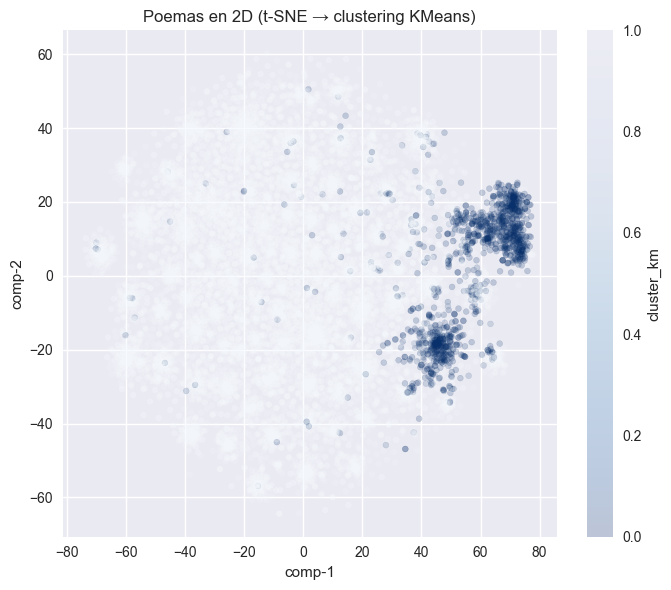

In [47]:
# Visualización 2D (matplotlib)
fig, ax = plt.subplots(figsize=(7,6))
sc = ax.scatter(X2[:,0], X2[:,1], c=new_poems_df["cluster_km"], s=18, alpha=0.2, cmap="Blues_r")
ax.set_title(
    f"Poemas en 2D ({reducer_name} → clustering KMeans)"
)
ax.set_xlabel("comp-1"); ax.set_ylabel("comp-2")
plt.colorbar(sc, ax=ax, label="cluster_km")
plt.tight_layout(); plt.show()

### La apariencia “orgánica”:

Las ramificaciones son poemas que comparten similitudes con varios grupos → quedan como “puentes” o “brazos”.

Los nudos o concentraciones (zonas densas) son grupos de poemas con vocabulario/emoción muy parecida.

El hecho de que se vean como filamentos o bacterias es porque UMAP estira el espacio para mostrar continuidad entre regiones.

### Interpretación práctica

Si en el corpus hay poemas con temas/emociones muy conectados (por ejemplo, dolor ↔ muerte ↔ desesperanza en Vallejo), UMAP los hilvana en curvas continuas.

Si fueran más disjuntos (ej. poemas amorosos vs poemas políticos), verías islas separadas, no ramificaciones.

En poesía esto es natural: los temas no son rígidos, sino que fluyen de uno a otro. El gráfico refleja precisamente esa transición semántica difusa.

In [ ]:
# Similitud coseno (matriz y top-k vecinos)

# matriz de similitud (calculada)
# cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

# top-k por coseno (equivalente a recomendador)
nn = NearestNeighbors(metric="cosine", algorithm="brute")
nn.fit(X_features)
dists, idxs = nn.kneighbors(X_features, n_neighbors=6)  # incluye el propio (dist=0)

In [49]:
# ejemplo: vecinos del título 'black herald'
q = new_poems_df.index[new_poems_df.title=="The Black Heralds"][0]
vecinos = idxs[q][1:]  # sin el mismo
new_poems_df.title.iloc[vecinos]

623                     aim song
9313          ballad salvat armi
1822    keumganggul diamond cave
6145                     fortuna
3259               way wind blow
Name: title, dtype: object

## Integración de resultados: supervisado + no supervisado

Esta sección materializa el bloque **Integración de Resultados** del flujo del README. Combina:

- clusters no supervisados (`KMeans`, `GMM`, `Agglomerative`, `DBSCAN`),
- tópicos LDA,
- similitudes por coseno y correlación,
- predicciones supervisadas de etiquetas poéticas.

El objetivo es responder: **¿los clusters emergentes coinciden con emociones o temas predichos por el modelo supervisado?**

In [50]:
# Imports adicionales para la integración supervisada/no supervisada
import ast
import warnings

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB, MultinomialNB
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import jaccard_score, roc_auc_score
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)

### Preparar etiquetas supervisadas

El dataset de Poetry Foundation contiene etiquetas en la columna `tags`. Estas etiquetas se transforman a formato multilabel usando `MultiLabelBinarizer`, para entrenar un clasificador que luego predice etiquetas sobre el corpus integrado (`Poetry Foundation + Vallejo`).

In [51]:
def parse_tags(value):
    """
    Convierte la columna tags a lista de etiquetas.
    Soporta valores que ya son listas o strings tipo "['Love', 'Nature']".
    """
    if isinstance(value, list):
        return value

    if pd.isna(value):
        return []

    try:
        parsed = ast.literal_eval(value)
        return parsed if isinstance(parsed, list) else [str(parsed)]
    except (ValueError, SyntaxError):
        return [
            tag.strip()
            for tag in str(value).split(Constants.COMMA_STR)
            if tag.strip()
        ]


poetry_df["tags"] = poetry_df["tags"].apply(parse_tags)

poetry_supervised_df: PandasDF = (
    poetry_df
    .loc[poetry_df["tags"].map(len) > 0, ["title", "poem", "tags"]]
    .dropna(subset=["poem"])
    .reset_index(drop=True)
)

display(poetry_supervised_df.head(3))

,title,poem,tags
0,invis fish,invis fish swim ghost ocean describ wave sand waterworn rock soon fish learn walk human come ashor paint dream die stone later later ocean floor punctuat chevi truck carri dreamer decend go store,"[living, time brevity, relationships, family ancestors, nature, landscapes pastorals, seas, rivers, streams, social commentaries, history politics]"
1,not bother earth spirit,not bother earth spirit live work stori oldest stori world delic chang see watch invit coffe warm bread oblig stay listen ordinari stori endur earthquak lightn death love blind beauti stori compel want leav trap stone finger escap,"[religion, the spiritual, mythology folklore, fairytales legends]"
2,hour consid hydrangea,hour consid hydrangea salt sand plant variet question variet diet mother know pound feel like lose lose ye sens possibl beauti grow extern extern beauti beauti occur surfac plant sun darken skin child small beauti obviou beauti hand swell bite spread insect venom small appear feel smash skull floor scream hold lap kitchen floor open freezer press pack frozen clay forehead like cold obviou hydrangea walk push child stroller walk push haul lift have bodi adjunct bodi compos errand weight tender small power imagin feel small weight pound like interf twitch muscl bodi object mother confus middleag mother littl spare flesh feel inch major muscl pull graviti weight child sleep hour think hydrangea let man look stop brush drowsi child littl eye face bare consid mother consid miss subtl power differenti time mass apprehen,"[living, parenthood, the body, the mind, nature, trees flowers]"


### Entrenar modelo supervisado multilabel

Se entrena una rama supervisada equivalente al flujo del README:

`build_feature_pipeline()` → `OneVsRestClassifier` → `StackingClassifier` → `ComplementNB + MultinomialNB` → `LogisticRegression`.

Este modelo se usa después para predecir etiquetas sobre todos los poemas integrados.

In [ ]:
seed: int = 42

mlb = MultiLabelBinarizer()
y_mlb = mlb.fit_transform(poetry_supervised_df["tags"])

X_train, X_test, y_train, y_test = train_test_split(
    poetry_supervised_df["poem"].tolist(),
    y_mlb,
    test_size=0.20,
    random_state=seed
)

pipeline_feature_sup: Pipeline = build_feature_pipeline()

pipeline_stack: Pipeline = Pipeline([
    ("Stack", OneVsRestClassifier(
        StackingClassifier(
            estimators=[
                ("cnb", ComplementNB(alpha=0.1)),
                ("mnb", MultinomialNB(alpha=0.099)),
            ],
            cv=KFold(n_splits=5, shuffle=True, random_state=seed),
            passthrough=True,
            final_estimator=LogisticRegression(
                random_state=seed,
                max_iter=1000
            )
        )
    ))
])

pipeline_full: Pipeline = Pipeline([
    ("features", pipeline_feature_sup),
    ("classifier", pipeline_stack),
])

pipeline_full.fit(X_train, y_train)

y_pred = pipeline_full.predict(X_test)

print(
    "Jaccard Score Micro:",
    round(jaccard_score(y_test, y_pred, average="micro"), 4)
)

try:
    y_score = pipeline_full.predict_proba(X_test)
    print(
        "ROC AUC Micro:",
        round(roc_auc_score(y_test, y_score, average="micro"), 4)
    )
except Exception as exc:
    print(f"No fue posible calcular ROC AUC con probabilidades: {exc}")

/Users/ronaldmendoza/Documents/Documents/Repos/GitHub/projects/_hubertronald/VersoVector/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:1426: RuntimeWarning: Number of classes in training fold (1) does not match total number of classes (2). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(
/Users/ronaldmendoza/Documents/Documents/Repos/GitHub/projects/_hubertronald/VersoVector/.venv/lib/python3.10/site-packages/sklearn/model_selection/_validation.py:1426: RuntimeWarning: Number of classes in training fold (1) does not match total number of classes (2). Results may not be appropriate for your use case. To fix this, use a cross-validation technique resulting in properly stratified folds
  warnings.warn(


### Funciones auxiliares de similitud

Estas funciones generalizan las recomendaciones por similitud coseno y correlación de Pearson para todos los poemas. Luego sus salidas se integran en un único dataframe de resultados.

In [ ]:
def get_top_neighbors_by_cosine(
    cosine_sim: np.ndarray,
    df: pd.DataFrame,
    top_n: int = 5
) -> tuple[list[list[str]], list[list[float]]]:
    """
    Retorna los vecinos más similares por coseno para cada poema.
    """
    all_titles = df["title"].tolist()

    nearest_titles = []
    nearest_scores = []

    for idx in range(len(df)):
        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

        # Excluir el mismo poema
        sim_scores = sim_scores[1: top_n + 1]

        titles = [all_titles[i] for i, _ in sim_scores]
        scores = [round(score, 4) for _, score in sim_scores]

        nearest_titles.append(titles)
        nearest_scores.append(scores)

    return nearest_titles, nearest_scores


def get_top_neighbors_by_corr(
    corr_matrix: pd.DataFrame,
    top_n: int = 5
) -> tuple[list[list[str]], list[list[float]]]:
    """
    Retorna vecinos más similares por correlación de Pearson para cada poema.
    """
    nearest_titles = []
    nearest_scores = []

    for title in corr_matrix.columns:
        sim_scores = corr_matrix[title].drop(title)
        sim_scores = sim_scores.sort_values(ascending=False).head(top_n)

        nearest_titles.append(sim_scores.index.tolist())
        nearest_scores.append(sim_scores.round(4).tolist())

    return nearest_titles, nearest_scores


nearest_titles_cosine, nearest_scores_cosine = get_top_neighbors_by_cosine(
    cosine_sim=cosine_sim,
    df=new_poems_df,
    top_n=5
)

nearest_titles_corr, nearest_scores_corr = get_top_neighbors_by_corr(
    corr_matrix=corr_matrix,
    top_n=5
)

### Construir `df_integracion`

Este dataframe integra los resultados principales del análisis:

- clusters (`cluster_km`, `cluster_gmm`, `cluster_agg`, `cluster_dbscan`),
- tópico dominante LDA,
- términos representativos del tópico,
- etiquetas predichas por el modelo supervisado,
- vecinos por similitud coseno y correlación,
- coordenadas 2D para visualización.

In [ ]:
# Integración de Resultados

# 1. Predicciones supervisadas sobre todo el corpus integrado
pred_tags = mlb.inverse_transform(
    pipeline_full
    .predict(
        new_poems_df["poem_processed" if INPUT_IS_PROCESSED else "poem_raw"]
        .tolist()
    )
)

# 2. Topico dominante por poema
lda_topic_id = lda_topics.argmax(axis=1)
lda_topic_prob = lda_topics.max(axis=1)

topic_terms = {
    topic_id: Constants.COMMA_STR.join(words[:5])
    for topic_id, words in top_words
}

# 3. DataFrame integrado
df_integracion: PandasDF = pd.DataFrame({
    "title": new_poems_df["title"].values,
    "poet": new_poems_df["poet"].values,
    "source": new_poems_df["source"].values,
    "original_tags": new_poems_df["tags"].values,

    # Clusters no supervisados
    "cluster_km": new_poems_df["cluster_km"].values,
    "cluster_gmm": new_poems_df["cluster_gmm"].values,
    "cluster_agg": new_poems_df["cluster_agg"].values,
    "cluster_dbscan": new_poems_df["cluster_dbscan"].values,

    # LDA
    "lda_topic_id": lda_topic_id,
    "lda_topic_prob": lda_topic_prob.round(4),
    "lda_topic_terms": [
        topic_terms.get(topic_id, "")
        for topic_id in lda_topic_id
    ],

    # Supervisado
    "predicted_tags": list(map(list, pred_tags)),

    # Similitud coseno
    "nearest_titles_cosine": nearest_titles_cosine,
    "nearest_scores_cosine": nearest_scores_cosine,

    # Correlacion Pearson
    "nearest_titles_corr": nearest_titles_corr,
    "nearest_scores_corr": nearest_scores_corr,

    # Coordenadas 2D
    "embedding_x": X2[:, 0],
    "embedding_y": X2[:, 1],
})

display(df_integracion.head(10))

### Clusters vs. etiquetas supervisadas

Este cruce permite contrastar si los clusters emergentes del análisis no supervisado coinciden con las etiquetas predichas por el modelo supervisado.

In [ ]:
df_exploded = (
    df_integracion
    .explode("predicted_tags")
    .dropna(subset=["predicted_tags"])
)

cluster_tag_matrix = pd.crosstab(
    df_exploded["cluster_km"],
    df_exploded["predicted_tags"],
    normalize="index"
).round(3)

display(cluster_tag_matrix)

In [ ]:
cluster_tag_counts = pd.crosstab(
    df_exploded["cluster_km"],
    df_exploded["predicted_tags"]
)

display(cluster_tag_counts)

### Clusters vs. tópicos LDA

Este cruce permite observar si los clusters geométricos se alinean con tópicos latentes del corpus.

In [ ]:
cluster_topic_matrix = pd.crosstab(
    df_integracion["cluster_km"],
    df_integracion["lda_topic_id"],
    normalize="index"
).round(3)

display(cluster_topic_matrix)

cluster_topic_summary = (
    df_integracion
    .groupby(["cluster_km", "lda_topic_id", "lda_topic_terms"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster_km", "count"], ascending=[True, False])
)

display(cluster_topic_summary)

### Resumen interpretativo por cluster

Esta tabla muestra las etiquetas supervisadas más frecuentes dentro de cada cluster no supervisado.

In [ ]:
cluster_tag_summary = (
    df_exploded
    .groupby(["cluster_km", "predicted_tags"])
    .size()
    .reset_index(name="count")
    .sort_values(["cluster_km", "count"], ascending=[True, False])
)

top_tags_by_cluster = (
    cluster_tag_summary
    .groupby("cluster_km")
    .head(5)
    .reset_index(drop=True)
)

display(top_tags_by_cluster)

### Análisis por poeta y fuente

Esta sección usa la metadata `poet` y `source` para interpretar los resultados del modelo.

- `poet` permite analizar si ciertos autores tienden a concentrarse en determinados clusters o etiquetas predichas.
- `source` permite validar la trazabilidad del corpus, por ejemplo Poetry Foundation vs. César Vallejo.
- `original_tags` se conserva como metadata del dataset original, pero no debe usarse como feature para evitar fuga de información.

La idea es usar `poet`, `source` y `original_tags` para interpretación, no para entrenar el modelo.

In [ ]:
# Clusters por poeta
# Esta matriz responde:
# ¿Hay clusters donde se concentran ciertos poetas?

cluster_poet_matrix = pd.crosstab(
    df_integracion["cluster_km"],
    df_integracion["poet"],
    normalize="index"
).round(3)

display(cluster_poet_matrix)

In [ ]:
# Conteo absoluto de poemas por cluster y poeta
# Útil cuando la matriz normalizada es difícil de leer
# o cuando hay muchos poetas con pocos poemas.

cluster_poet_counts = pd.crosstab(
    df_integracion["cluster_km"],
    df_integracion["poet"]
)

display(cluster_poet_counts)

In [ ]:
# Fuente de datos por cluster
# Esta matriz ayuda a revisar si los clusters están sesgados
# por la fuente del corpus: Poetry Foundation vs César Vallejo.

cluster_source_matrix = pd.crosstab(
    df_integracion["cluster_km"],
    df_integracion["source"],
    normalize="index"
).round(3)

display(cluster_source_matrix)

### Tags predichos por poeta

Esta tabla permite observar qué tonos o temas tiende a predecir el modelo para cada poeta.

En el caso de César Vallejo, esto sirve para contrastar cómo sus poemas traducidos al inglés son leídos por el clasificador entrenado sobre Poetry Foundation.

In [ ]:
# Tags predichos por poeta

df_pred_tags = (
    df_integracion
    .explode("predicted_tags")
    .dropna(subset=["predicted_tags"])
)

poet_tag_matrix = pd.crosstab(
    df_pred_tags["poet"],
    df_pred_tags["predicted_tags"],
    normalize="index"
).round(3)

display(poet_tag_matrix)

In [ ]:
# Conteo absoluto de tags predichos por poeta

poet_tag_counts = pd.crosstab(
    df_pred_tags["poet"],
    df_pred_tags["predicted_tags"]
)

display(poet_tag_counts)

### Vallejo frente al corpus

Esta vista permite observar cómo se ubican los poemas de César Vallejo dentro del corpus general:

- en qué cluster caen,
- qué tópico LDA domina,
- qué términos representa ese tópico,
- qué etiquetas supervisadas predice el modelo,
- y cuáles son sus poemas más cercanos por similitud coseno.

In [ ]:
# César Vallejo frente al corpus

vallejo_view = (
    df_integracion[
        df_integracion["poet"].eq("César Vallejo")
        | df_integracion["source"].eq("cesar_vallejo")
        | df_integracion["title"].str.contains("black herald|vallejo", case=False, na=False)
    ][
        [
            "title",
            "poet",
            "source",
            "cluster_km",
            "cluster_gmm",
            "cluster_agg",
            "cluster_dbscan",
            "lda_topic_id",
            "lda_topic_prob",
            "lda_topic_terms",
            "predicted_tags",
            "nearest_titles_cosine",
            "nearest_scores_cosine"
        ]
    ]
    .reset_index(drop=True)
)

display(vallejo_view)

### Lectura metodológica

La regla de uso de variables queda así:

```text
poem_processed  → features/modelos
tags            → variable objetivo supervisada
poet/source     → análisis e interpretación
original_tags   → metadata original del dataset
predicted_tags  → resultado supervisado
clusters/topics → resultado no supervisado
```

De esta forma, el proyecto puede analizar emociones, temas y estilo literario por autor sin contaminar el entrenamiento con metadata externa al poema.

### Visualización integrada

La visualización mantiene la proyección 2D de UMAP/t-SNE, coloreada por `cluster_km`, y resalta poemas asociados a Vallejo o a *black herald* cuando están presentes en el corpus.

In [ ]:
fig, ax = plt.subplots(figsize=(8, 7))

sc = ax.scatter(
    df_integracion["embedding_x"],
    df_integracion["embedding_y"],
    c=df_integracion["cluster_km"],
    s=18,
    alpha=0.25,
    cmap="Blues_r"
)

ax.set_title(
    "Integración no supervisada: UMAP/t-SNE + KMeans + etiquetas supervisadas"
)
ax.set_xlabel("comp-1")
ax.set_ylabel("comp-2")

plt.colorbar(sc, ax=ax, label="cluster_km")

# Anotar poemas de Vallejo si están en el dataframe
mask_vallejo = df_integracion["title"].str.contains(
    "black herald|vallejo",
    case=False,
    na=False
)

for _, row in df_integracion[mask_vallejo].iterrows():
    ax.annotate(
        row["title"],
        xy=(row["embedding_x"], row["embedding_y"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9,
        weight="bold"
    )

plt.tight_layout()
plt.show()

### Exportar resultados integrados

Se guarda un CSV con la integración de clusters, tópicos, similitudes y etiquetas predichas. Este archivo puede usarse luego para análisis externo, visualización o documentación en el README.

In [ ]:
output_path = here / "data" / "integrated_results.csv"

df_integracion.to_csv(
    output_path,
    index=False,
    encoding=Constants.ENCODING,
    sep=Constants.PIPE_STR
)

print(f"Archivo generado: {output_path}")

### Visualización completa del pipeline

GitHub no renderiza diagramas HTML interactivos generados por scikit-learn.
Para ver la representación visual completa del pipeline, utiliza **nbviewer**:

[04_embeddings_unsupervised.ipynb](https://nbviewer.org/github/HubertRonald/VersoVector/blob/main/notebook/04_embeddings_unsupervised.ipynb)